In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
import json

with open("data/json/track_ID2_1200.json", "r") as f:
    track_data = json.load(f)

df = pd.json_normalize(track_data).explode(["data.x_values", "data.y_values"])
    
df

,value_id,vehicle_id,state,value_description.name_de,value_description.name_en,value_description.variable_name,value_description.unit,value_description.min_val,value_description.max_val,data.x_values,data.y_values
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,0.0,0.0
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,1.0,0.0
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,2.0,0.0
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,3.0,0.0
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,495.0,0.0
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,496.0,0.0
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,497.0,0.0
0,1200,ID2,track,Packspannung,pack voltage,hv_battery_voltage,V,0.0,1000.0,498.0,0.0


Text(0.5, 1.0, 'Histogram of hv_battery_voltage of car ID2 during driving')

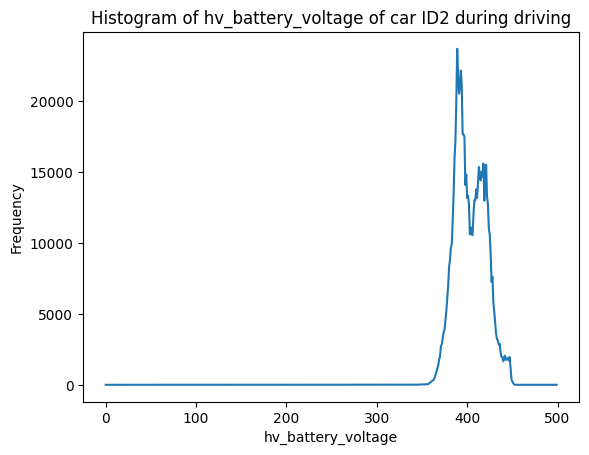

In [8]:
state = 'driving' if df['state'].values[0] else 'charging'
vehicle_id = df['vehicle_id'].values[0]
variable_name = df['value_description.variable_name'].values[0]

plt.plot(df["data.x_values"], df["data.y_values"])    
plt.xlabel(df['value_description.variable_name'].values[0])
plt.ylabel('Frequency')
plt.title(f"Histogram of {variable_name} of car {vehicle_id} during {state}")

<Axes: xlabel='time'>

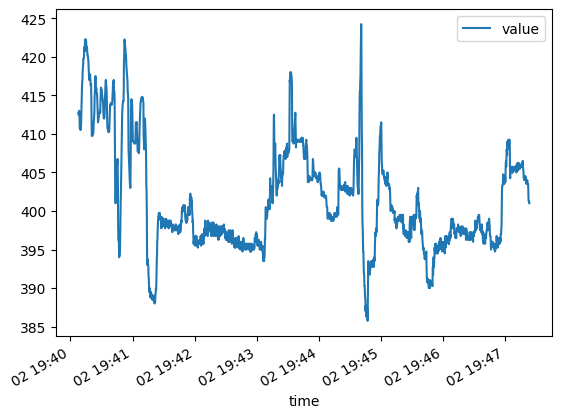

In [9]:
df = pd.read_parquet(f"data/uds_data/ID1.parquet")
df.loc[df['value_id'] == 1200].sort_values('time').iloc[1000:3000].plot(x='time', y='value')